In [1]:
import pandas as pd

df = pd.read_csv("cleaned_student_dataset.csv")

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Student_ID     1000 non-null   object
 1   Name           1000 non-null   object
 2   Date_of_Birth  1000 non-null   object
 3   Gender         1000 non-null   object
 4   Course         1000 non-null   object
 5   Year           1000 non-null   int64 
 6   City           1000 non-null   object
 7   Email          1000 non-null   object
 8   Age            1000 non-null   int64 
dtypes: int64(2), object(7)
memory usage: 70.4+ KB


In [4]:
df['Age_Category'] = df['Age'].apply(lambda x: 'Young' if x <= 20 else 'Adult')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Student_ID     1000 non-null   object        
 1   Name           1000 non-null   object        
 2   Date_of_Birth  1000 non-null   datetime64[ns]
 3   Gender         1000 non-null   object        
 4   Course         1000 non-null   object        
 5   Year           1000 non-null   int64         
 6   City           1000 non-null   object        
 7   Email          1000 non-null   object        
 8   Age            1000 non-null   int64         
 9   Age_Category   1000 non-null   object        
dtypes: datetime64[ns](1), int64(2), object(7)
memory usage: 78.3+ KB


# Total Students 
Total Students=COUNT(Student_id)

In [6]:
total_students = df['Student_ID'].count()
print(total_students)

1000


 # Most Popular Course

In [8]:
df['Course'].value_counts()


Course
BBA       220
BA        198
B.Tech    196
B.Sc      194
B.Com     192
Name: count, dtype: int64

# Gender Distribution

In [9]:
df['Gender'].value_counts()

Gender
F    514
M    486
Name: count, dtype: int64

# Top City by Enrollment

In [10]:
df['City'].value_counts().head()

City
Bengaluru    111
Pune         106
Kochi        102
Hyderabad    102
Kolkata      101
Name: count, dtype: int64

# Deep dive analysis

In [12]:
def age_segment(age):
    if age <= 20:
        return "Young"
    elif age <= 22:
        return "Mid Age"
    else:
        return "Senior"

df["Age_Segment"] = df["Age"].apply(age_segment)

segment_analysis = df.groupby("Age_Segment").size()
print(segment_analysis)

Age_Segment
Mid Age    332
Senior     202
Young      466
dtype: int64


Course
BBA       220
BA        198
B.Tech    196
B.Sc      194
B.Com     192
Name: count, dtype: int64


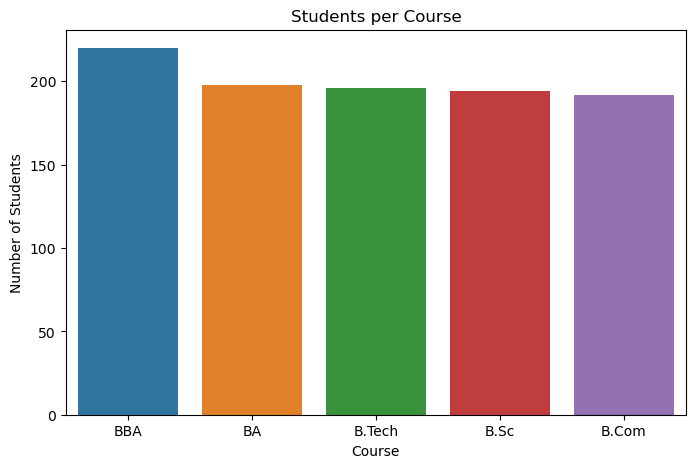

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
course_counts = df['Course'].value_counts()
print(course_counts)
plt.figure(figsize=(8,5))
sns.barplot(x=course_counts.index, y=course_counts.values)

plt.title("Students per Course")
plt.xlabel("Course")
plt.ylabel("Number of Students")

plt.show()

Year
1    248
2    264
3    247
4    241
Name: count, dtype: int64


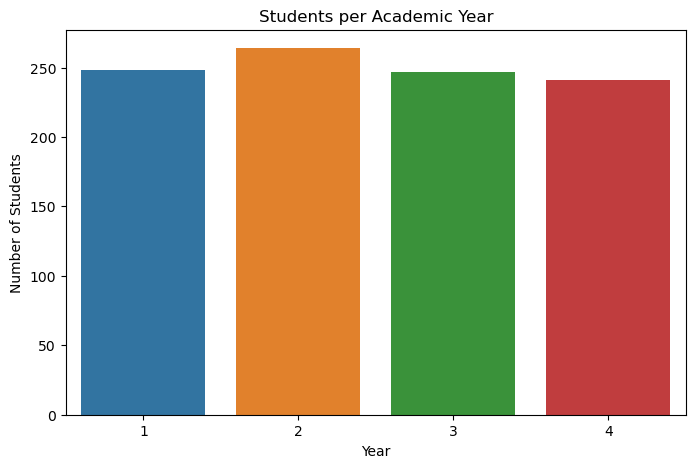

In [19]:
year_counts = df['Year'].value_counts().sort_index()

print(year_counts)
plt.figure(figsize=(8,5))
sns.barplot(x=year_counts.index, y=year_counts.values)

plt.title("Students per Academic Year")
plt.xlabel("Year")
plt.ylabel("Number of Students")

plt.show()

In [20]:
course_year = pd.pivot_table(
    df,
    values='Student_ID',
    index='Course',
    columns='Year',
    aggfunc='count'
)

print(course_year)

Year     1   2   3   4
Course                
B.Com   38  61  46  47
B.Sc    38  57  57  42
B.Tech  52  50  44  50
BA      63  47  42  46
BBA     57  49  58  56


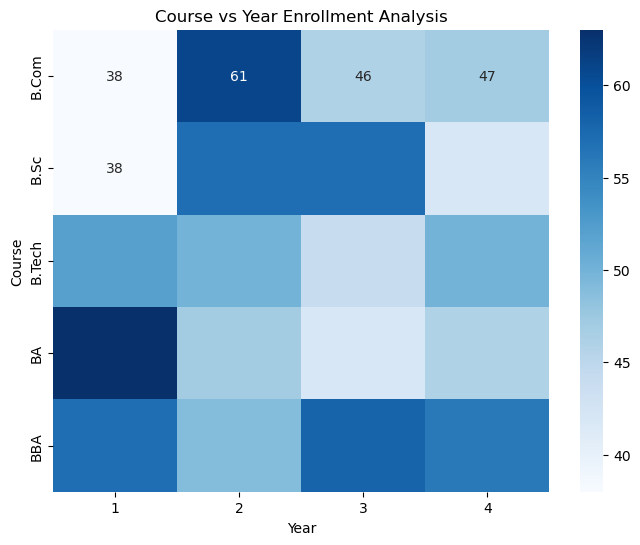

In [21]:
plt.figure(figsize=(8,6))

sns.heatmap(course_year,
            annot=True,
            cmap="Blues",
            fmt="d")

plt.title("Course vs Year Enrollment Analysis")

plt.show()